In [1]:
import cloudpickle

results_pikl = "pikls/20260115_133527/all_datasets_full.pkl"
#TChiWZ_17_pikl = "pikls/20251219_142853/TChiWZ2017UL.pkl"

with open(results_pikl, "rb") as f:
    json = cloudpickle.load(f)
    results = json["results"]

In [2]:
results.keys()

dict_keys(['WtoLNu_2Jets_2023', 'TChiWZ_2018UL', 'TChiWZ_2017UL', 'TTto2L2Nu_2017UL', 'WWTo2L2Nu_2017UL', 'TTtoLNu_2023'])

In [3]:
from plotting.pt_eta_eff import plot_eta_pt_eff
from plotting.pt_eff_gsb import make_AN_1d_pt_eff

In [4]:
import matplotlib.pyplot as plt
import mplhep

In [5]:
make_ele_sig_2d = True
make_ele_lf_2d  = True
make_ele_hf_2d  = True
make_ele_1d_eff = True
make_mu_sig_2d  = True
make_mu_lf_2d   = True
make_mu_hf_2d   = True
make_mu_1d_eff  = True

# SIGNAL (GenFlav = 1)

In [6]:
sample_display_names = {
    'WtoLNu_2Jets_2023': r'$W \to \ell\nu$ + 2Jets (2023)',
    'TChiWZ_2018UL': 'TChiWZ 2018 UL',
    'TChiWZ_2017UL': 'TChiWZ 2017 UL',
    'TTto2L2Nu_2017UL': r'$t\bar{t} \to 2\ell 2\nu$ (2017 UL)',
    'WWTo2L2Nu_2017UL': r'$WW \to 2\ell 2\nu$ (2017 UL)',
    'TTtoLNu_2023': r'$t\bar{t} \to \ell\nu$ (2023)'
}

sample_file_names = {
    'WtoLNu_2Jets_2023': 'Wjets_2023',
    'TChiWZ_2018UL': 'TChiWZ_2018UL',
    'TChiWZ_2017UL': 'TChiWZ_2017UL',
    'TTto2L2Nu_2017UL': 'TTbar_2L2Nu_2017UL',
    'WWTo2L2Nu_2017UL': 'WW_2L2Nu_2017UL',
    'TTtoLNu_2023': 'TTbar_LNu_2023'
}

WtoLNu_2Jets_2023
(Hist(
  Variable([2, 3, 4, 5, 7, 10, 20, 45, 75, 1000], name='pt', label='Electron $p_T$ (GeV)'),
  Variable([0, 0.8, 1.4442, 1.556, 2.5], name='eta', label='Electron $\\eta$'),
  storage=Double()) # Sum: nan (nan with flow), array([[0.02498969, 0.03179664,        nan,        nan],
       [0.016481  , 0.02143732,        nan,        nan],
       [0.01395629, 0.0163503 ,        nan,        nan],
       [0.00771045, 0.00976089,        nan,        nan],
       [0.00463219, 0.00597087,        nan,        nan],
       [0.0012958 , 0.00155895, 0.00552388, 0.00159107],
       [0.00045019, 0.00051594, 0.00210396, 0.0005099 ],
       [0.00086742, 0.00104994, 0.00431533, 0.00107326],
       [0.00181391, 0.00224305, 0.00928946, 0.00235039]]))
[   2.    3.    4.    5.    7.   10.   20.   45.   75. 1000.]
['2 - 3', '3 - 4', '4 - 5', '5 - 7', '7 - 10', '10 - 20', '20 - 45', '45 - 75', '75 - 1000']
range(0, 10)
[0.     0.8    1.4442 1.556  2.5   ]
['0 $< |\\eta| \\leq$ 0.8', '0.8 $<

FileNotFoundError: [Errno 2] No such file or directory: 'el_2d/Wjets_2023_signal_ele.pdf'

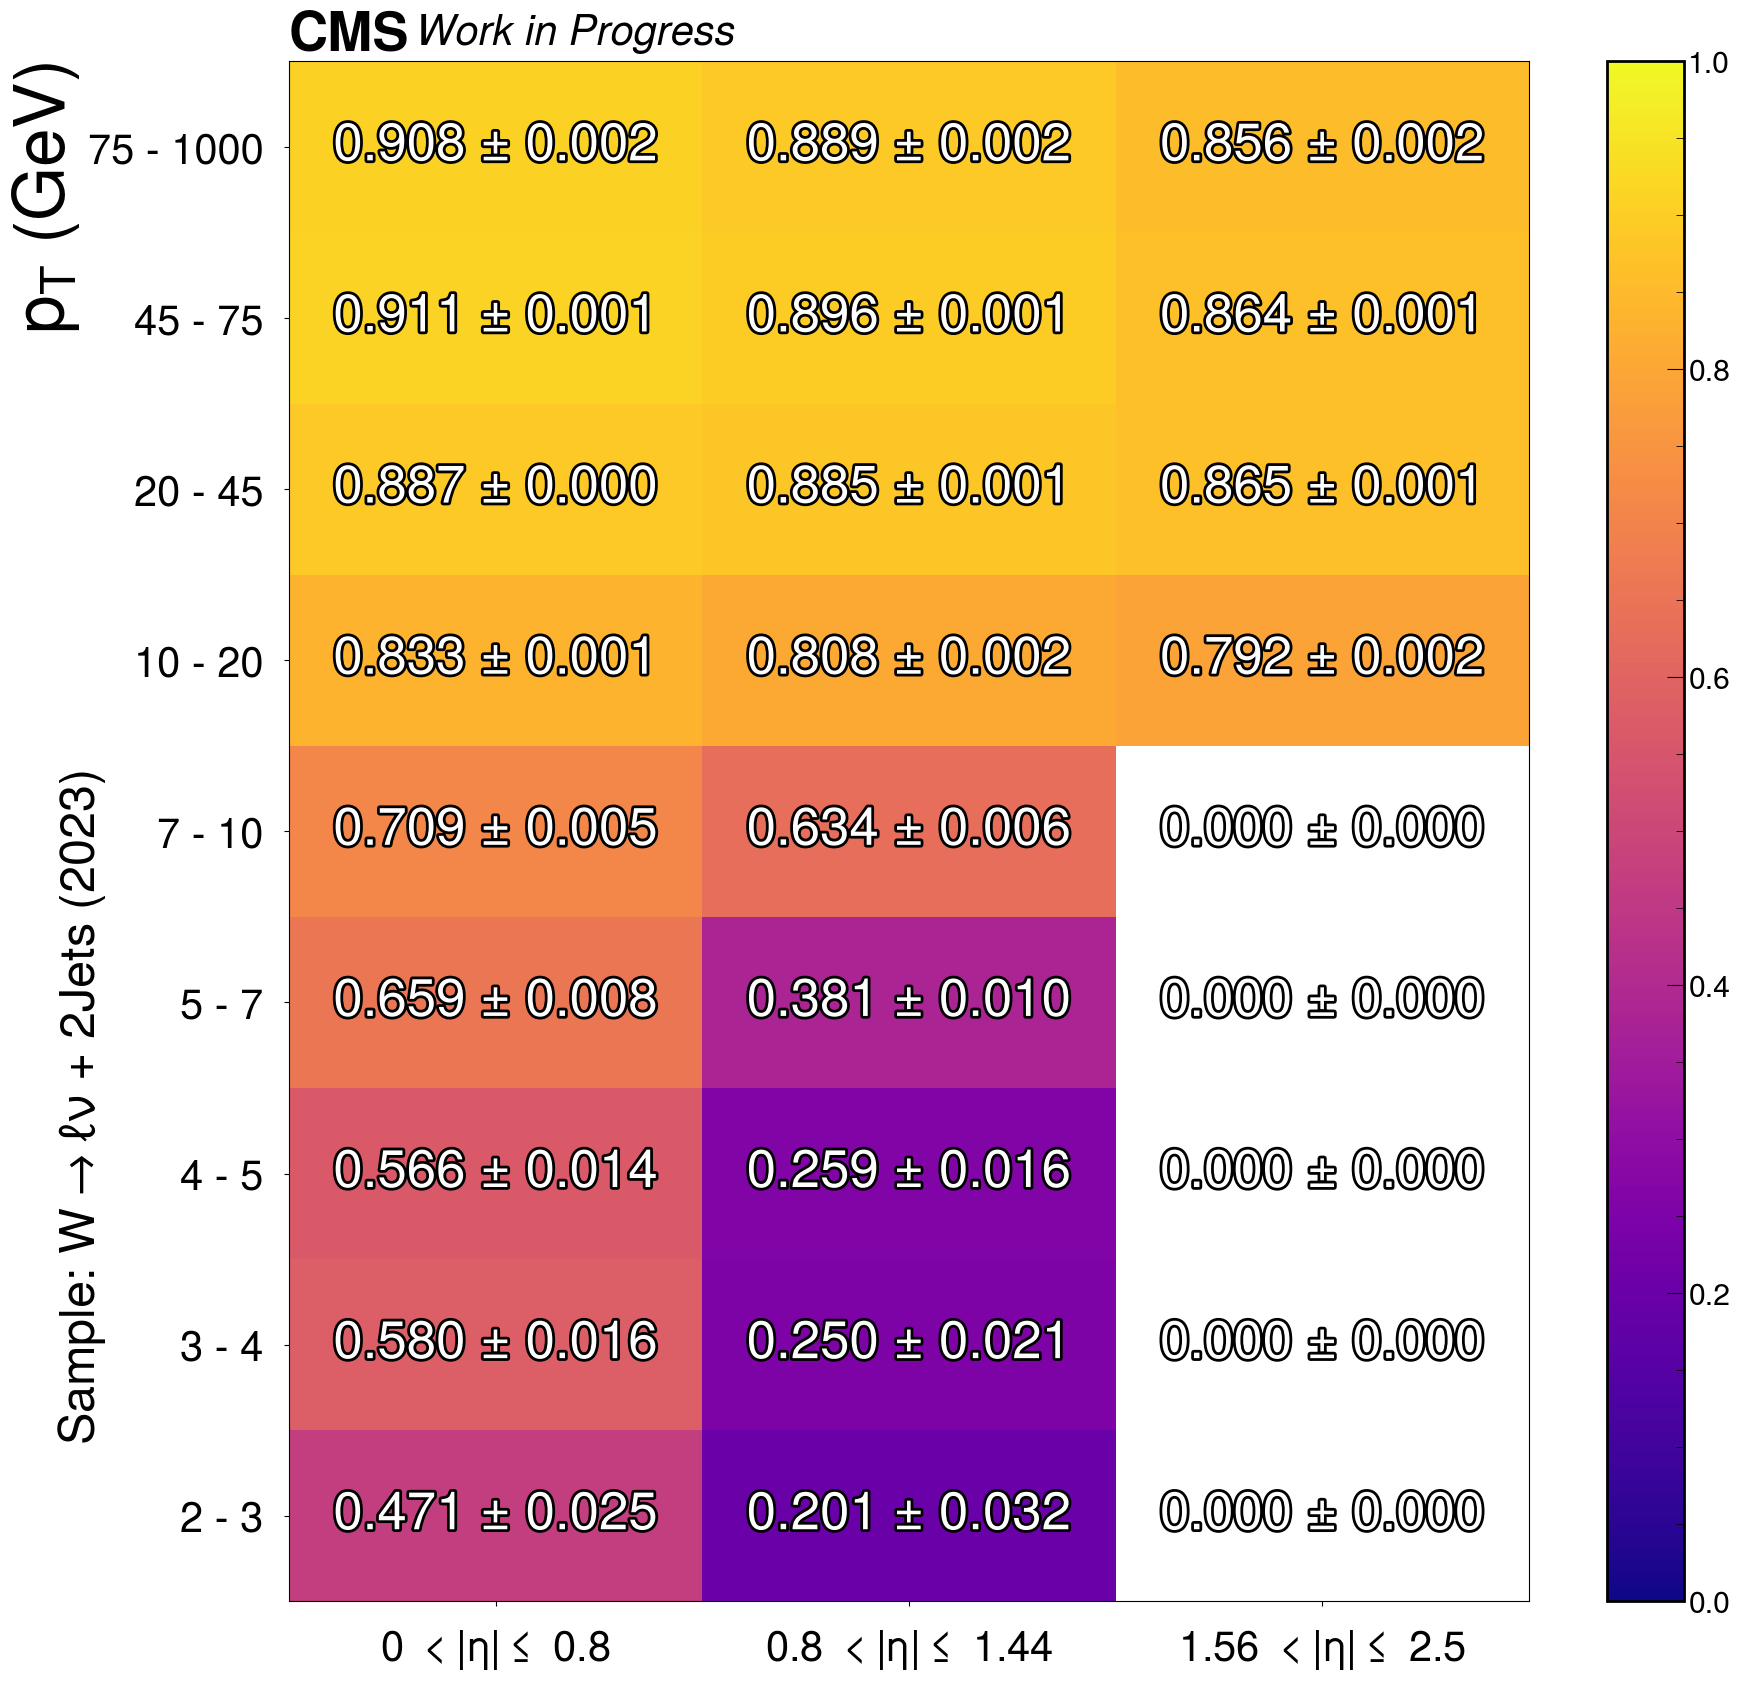

In [7]:
for key in list(results.keys()):
    print(key)
    
    hist = results[key]['ele_hist']
    
    # Numerator: gold prompt electrons (integrate pt_long, select gen=1, qual=100)
    numerator = hist.integrate("pt_long")[:, :, 1j, 100j]  # [pt, eta]
    
    # Denominator: baseline prompt electrons (integrate pt_long and qual over baseline, select gen=1)
    denominator = hist.integrate("pt_long").integrate("qual", [1j, 10j, 100j])[:, :, 1j]  # [pt, eta]

    # Get custom sample name, fallback to first 20 chars if not in map
    sample_name = sample_display_names.get(key, key[:20])
    
    file_name = sample_file_names.get(key, key[:20])

    if make_ele_sig_2d:
        plot_eta_pt_eff(
            numerator, 
            denominator,
            "",
            sample_name=sample_name,
            save_name=f"{file_name}_signal_ele",
            color='plasma',
            save_fig=True,
            plot_directory="el_2d",
            vmin=0,
            vmax=1,
            event_count=None,
            com=13 
        )
    

# LightFakes (GenFlav = 0)

In [ ]:
for key in list(results.keys()):
    print(key)
    
    hist = results[key]['ele_hist']
    
    # Numerator: gold prompt electrons (integrate pt_long, select gen=1, qual=100)
    numerator = hist.integrate("pt_long")[:, :, 10j, 100j]  # [pt, eta]
    
    # Denominator: baseline prompt electrons (integrate pt_long and qual over baseline, select gen=1)
    denominator = hist.integrate("pt_long").integrate("qual", [1j, 10j, 100j])[:, :, 10j]  # [pt, eta]

    # Get custom sample name, fallback to first 20 chars if not in map
    sample_name = sample_display_names.get(key, key[:20])
    
    file_name = sample_file_names.get(key, key[:20])

    if make_ele_lf_2d:
        plot_eta_pt_eff(
            numerator, 
            denominator,
            "",
            sample_name=sample_name,
            save_name=f"{file_name}_lf_ele",
            color='plasma',
            save_fig=True,
            plot_directory="el_2d",
            vmin=0,
            vmax=0.45,
            event_count=None,
            com=13 
        )
    

# HeavyFakes (GenFlav = 3/4?)

In [ ]:
for key in list(results.keys()):
    print(key)
    
    hist = results[key]['ele_hist']
    
    # Numerator: gold prompt electrons (integrate pt_long, select gen=1, qual=100)
    numerator = hist.integrate("pt_long")[:, :, 100j, 100j]  # [pt, eta]
    
    # Denominator: baseline prompt electrons (integrate pt_long and qual over baseline, select gen=1)
    denominator = hist.integrate("pt_long").integrate("qual", [1j, 10j, 100j])[:, :, 100j]  # [pt, eta]

    # Get custom sample name, fallback to first 20 chars if not in map
    sample_name = sample_display_names.get(key, key[:20])
    
    file_name = sample_file_names.get(key, key[:20])

    if make_ele_hf_2d:
        plot_eta_pt_eff(
            numerator, 
            denominator,
            "",
            sample_name=sample_name,
            save_name=f"{file_name}_hf_ele",
            color='plasma',
            save_fig=True,
            plot_directory="el_2d",
            vmin=0,
            vmax=0.45,
            event_count=None,
            com=13 
        )
    

In [ ]:
results[key]['ele_hist'].axes

# MUONS SIGNAL

In [ ]:
for key in list(results.keys()):
    print(key)
    
    hist = results[key]['muon_hist']
    
    # Numerator: gold prompt electrons (integrate pt_long, select gen=1, qual=100)
    numerator = hist.integrate("pt_long")[1:, :, 1j, 100j]  # [pt, eta]
    
    # Denominator: baseline prompt electrons (integrate pt_long and qual over baseline, select gen=1)
    denominator = hist.integrate("pt_long").integrate("qual", [1j, 10j, 100j])[1:, :, 1j]  # [pt, eta]

    # Get custom sample name, fallback to first 20 chars if not in map
    sample_name = sample_display_names.get(key, key[:20])
    
    file_name = sample_file_names.get(key, key[:20])

    make_mu_sig_2d:
        plot_eta_pt_eff(
            numerator, 
            denominator,
            "",
            sample_name=sample_name,
            save_name=f"{file_name}_signal_muon",
            color='plasma',
            save_fig=True,
            plot_directory="mu_2d",
            vmin=0,
            vmax=1,
            event_count=None,
            com=13 
        )
    

# MUONS LIGHT FAKES

In [ ]:
for key in list(results.keys()):
    print(key)
    
    hist = results[key]['muon_hist']
    
    # Numerator: gold prompt electrons (integrate pt_long, select gen=1, qual=100)
    numerator = hist.integrate("pt_long")[1:, :, 10j, 100j]  # [pt, eta]
    
    # Denominator: baseline prompt electrons (integrate pt_long and qual over baseline, select gen=1)
    denominator = hist.integrate("pt_long").integrate("qual", [1j, 10j, 100j])[1:, :, 10j]  # [pt, eta]

    # Get custom sample name, fallback to first 20 chars if not in map
    sample_name = sample_display_names.get(key, key[:20])
    
    file_name = sample_file_names.get(key, key[:20])

    if make_mu_lf_2d:
        plot_eta_pt_eff(
            numerator, 
            denominator,
            "",
            sample_name=sample_name,
            save_name=f"{file_name}_lf_muon",
            color='plasma',
            save_fig=True,
            plot_directory="mu_2d",
            vmin=0,
            vmax=.45,
            event_count=None,
            com=13 
        )
    

# MUONS HEAVY FAKES

In [ ]:
for key in list(results.keys()):
    print(key)
    
    hist = results[key]['muon_hist']
    
    # Numerator: gold prompt electrons (integrate pt_long, select gen=1, qual=100)
    numerator = hist.integrate("pt_long")[1:, :, 100j, 100j]  # [pt, eta]
    
    # Denominator: baseline prompt electrons (integrate pt_long and qual over baseline, select gen=1)
    denominator = hist.integrate("pt_long").integrate("qual", [1j, 10j, 100j])[1:, :, 100j]  # [pt, eta]

    # Get custom sample name, fallback to first 20 chars if not in map
    sample_name = sample_display_names.get(key, key[:20])
    
    file_name = sample_file_names.get(key, key[:20])

    if make_mu_hf_2d:
        plot_eta_pt_eff(
            numerator, 
            denominator,
            "",
            sample_name=sample_name,
            save_name=f"{file_name}_hf_muon",
            color='plasma',
            save_fig=True,
            plot_directory="mu_2d",
            vmin=0,
            vmax=0.45,
            event_count=None,
            com=13 
        )
    
    

# Do some integrate() or project() testing here:

In [ ]:
# ============= ELECTRONS =============
# TChiWZ 2017 signal vs TTbar 2017 fakes (ELECTRONS)
tchiwz_hist = results['TChiWZ_2017UL']['ele_hist']
ttbar_hist = results['TTto2L2Nu_2017UL']['ele_hist']

if make_ele_1d_eff:
    # 1. Regular (linear, up to 100 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_electron",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Electrons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Electron",
        com=13
    )
    
    # 2. Regular log (log scale, up to 100 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_electron",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Electrons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Electron",
        com=13,
        log_scale=True
    )
    
    # 3. Regular up to 30 GeV (linear, up to 30 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_electron_30GeV",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Electrons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Electron",
        com=13,
        max_pt=30
    )
    
    # 4. Log 30 GeV (log scale, up to 30 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_electron_30GeV",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Electrons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Electron",
        com=13,
        max_pt=30,
        log_scale=True
    )

if make_mu_1d_eff:
    # ============= MUONS =============
    # TChiWZ 2017 signal vs TTbar 2017 fakes (MUONS)
    tchiwz_hist = results['TChiWZ_2017UL']['muon_hist']
    ttbar_hist = results['TTto2L2Nu_2017UL']['muon_hist']
    
    # 1. Regular (linear, up to 100 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_muon",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Muons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Muon",
        com=13
    )
    
    # 2. Regular log (log scale, up to 100 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_muon",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Muons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Muon",
        com=13,
        log_scale=True
    )
    
    # 3. Regular up to 30 GeV (linear, up to 30 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_muon_30GeV",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Muons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Muon",
        com=13,
        max_pt=30
    )
    
    # 4. Log 30 GeV (log scale, up to 30 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_muon_30GeV",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Muons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Muon",
        com=13,
        max_pt=30,
        log_scale=True
    )

In [ ]:
"""
WtoLNu-2JetsTuneCP513p6TeVamcatnloFXFX-pythia8
SMS-TChiWZZToLLmZMin-0p1TuneCP513TeV-madgraphMLM-pythia8RunIISummer20UL18NanoAODv9-106Xupgrade2018realisticv16L1v1-v1NANOAODSIM
TChiWZ2017UL
TTto2L2Nu_2017UL
WWTo2L2Nu_2017UL
TTtoLNu_2023
"""